# DEF-D Fysieke Ontwerpopdracht 2 invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in (als in *PR* op GitHub en de link op Brightspace). Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 19     |  |
| :-------------|:-------------|
| Emma Jule Drent| 6507417 |
| Florian Spauwen| 6582303 |
| Casper Aaldering | 6243193 |
| Planning Groep: XX     |Tijdstip / Tijdspanne  |
|---|---|
| Sanity checks af | 12.00 |
| Condensator af| 12.45 |
| Schetsen voor sensor | 14.00 |
| Simulatie | 14.15 |
| Kalibratie | 15.00 |
| Itereren / afronden | 16.00 |
| Groep aanwezig | 10.45 |
| Pauze 1| 12.45-13.45 |
| Pauze 2| 15.00-15.15 |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
#from IPython import display
from IPython.display import Image, display

## *Opdracht 1*: Sanity check 3

#### Voeg hier een foto van de schets van je plaatcondensator in. Geef daarbij ook duidelijk de waarde van $A$ en $d$ aan.
<img src="Schets1.jpeg" alt="schets student 1" width="400"/>

In [2]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!
epsilon0 = 8.854e-12

def vlakkeplaat(epsilonr,A,d):
    C = (epsilon0 * epsilonr * A) / d     # Afstand tussen de twee platen << oppervlakte A platen. 
    return C


In [3]:
# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
# gaat zijn.

A = 0.01   # (m^2) oppervlakte platen
d = 0.001   # (m) afstand tussen de platen
epsilonr_karton = 2   # (F/m) permittiviteit van karton (stof tussen de platen)

C_verwacht = vlakkeplaat(epsilonr_karton,A,d) / 1e-12  # (pF)

print(f"Verwachte capaciteit plaatcondensator groep 19 is {C_verwacht:.1f} pF")



# Met osciloscoop berekend:
A_uit = 750e-3 # (V) amplitude van V_uit
A_in = 8    # (V)
f = 100e3   # (Hz) frequentie
R_sh = 1e3  # (Ohm) weerstand shunt
C_meting = A_uit / (2*np.pi*f*R_sh*A_in * 1e-12)

print(f"Berekende capaciteit plaatcondensator groep 19 is {C_meting:.1f} pF")



Verwachte capaciteit plaatcondensator groep 19 is 177.1 pF
Berekende capaciteit plaatcondensator groep 19 is 149.2 pF


#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
![scope meting 1](Condensator1.jpeg)
![scope meting 2](Condensator3.jpeg)

### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit   | Berekend Voltage | Gemeten Voltage | Gemeten capaciteit   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep 19| 177.1 pF | 0.89 V | 149.2 |0.75 V |

## *Opdracht 2:* Synthese.

#### Voeg hier voor een foto van je schets(en) van minimaal drie sensoren in.
![drie schetsen](Schets2.jpeg)


## Opdracht 3: Welke sensor gaan jullie maken?

Wij gaan een sensor maken die de afgelegde afstand van een plaat meet. Dit doen we door bovenste plaat van de condensator eraf te schuiven. Afnemende oppervlakte -> afnemende capaciteit -> toename in afgelegde afstand. Dit is haalbaar.

## Opdracht 4: Uitgewerkte schets (afmetingen!) en plot van de ontwerpgrafiek.

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
![uitgewerkte schets](Ontwerp.jpeg)

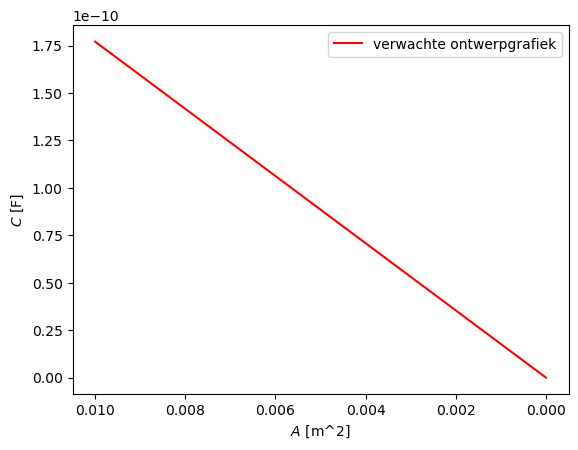

In [4]:
# Plot hier de verwachte ontwerpgrafiek van jullie sensoren.

A_var = np.linspace(0.01,0,1000) # (m^2) afnemend oppervlakte van 0.01 naar 0.

# Figuur plotten:
plt.figure()
plt.plot(A_var, vlakkeplaat(epsilonr_karton,A_var,d), "r-", label = "verwachte ontwerpgrafiek")
plt.xlabel("$A$ [m^2]")
plt.ylabel("$C$ [F]")
plt.legend()
plt.gca().invert_xaxis()
plt.show()

## Opdracht 5: Invullen tabel LTSpice.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 0 | 0 |
| gemiddelde capaciteit| 75 | 600 |
| maximale capaciteit| 150 | 750 |

## Opdracht 6: Foto's werkende opstelling.

#### Voeg hier de foto's van je sensoren in actie in.
![meting 1a](m1.jpeg)
![meting 1b](mo1.jpeg)
![meting 2a](m2.jpeg)
![meting 2b](m02.jpeg)

## Opdracht 7: Plot de kalibratiegrafiek.

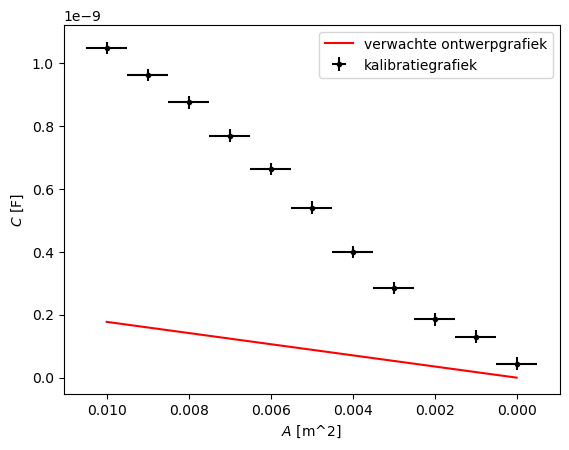

In [5]:
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.
A_kal = np.array([0.1,0.09,0.08,0.07,0.06,0.05,0.04,0.03,0.02,0.01,0])*0.1
C_kal = np.array([1047,960.5,874,768,662,540,399,285,185,130,44])*1e-12

plt.figure()
plt.plot(A_var, vlakkeplaat(epsilonr_karton,A_var,d), "r-", label = "verwachte ontwerpgrafiek")
plt.errorbar(A_kal, C_kal, xerr=0.0005, yerr=2e-11, fmt = "k.", label = "kalibratiegrafiek")
plt.xlabel("$A$ [m^2]")
plt.ylabel("$C$ [F]")
plt.legend()
plt.gca().invert_xaxis()
plt.show()


We gaan even kijken hoe we de verwachte ontwerpgrafiek laten passen op de kalibratiegrafiek.

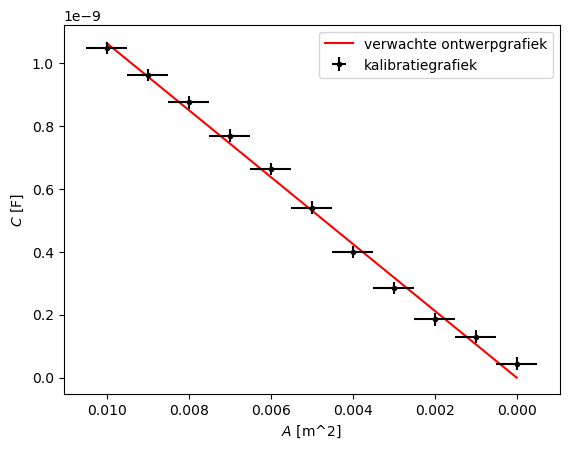

In [6]:
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.
A_kal = np.array([0.1,0.09,0.08,0.07,0.06,0.05,0.04,0.03,0.02,0.01,0])*0.1
C_kal = np.array([1047,960.5,874,768,662,540,399,285,185,130,44])*1e-12

plt.figure()
plt.plot(A_var, 6*vlakkeplaat(epsilonr_karton,A_var,d), "r-", label = "verwachte ontwerpgrafiek")
plt.errorbar(A_kal, C_kal, xerr=0.0005, yerr=2e-11, fmt = "k.", label = "kalibratiegrafiek")
plt.xlabel("$A$ [m^2]")
plt.ylabel("$C$ [F]")
plt.legend()
plt.gca().invert_xaxis()
plt.show()


Na het implementeren van een factor 6 op de verwachte ontwerpgrafiek, zien we dat de twee grafieken samenvallen. DIt is te wijden aan een afwijking in de meeting met arduino (achtergrondruis).

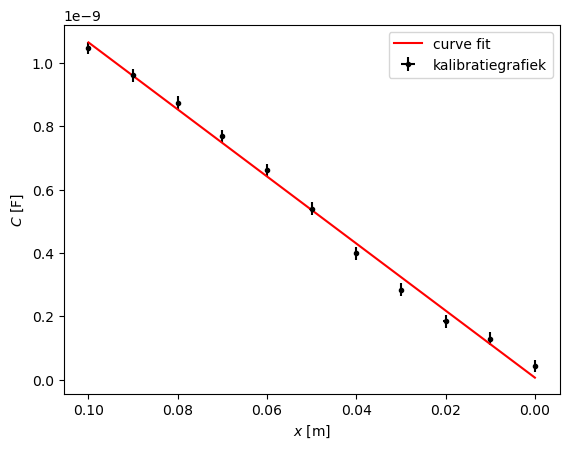

fit: C = 1.0575454423503925e-08*x + 7.090917662340709e-12


In [7]:
from scipy.optimize import curve_fit


x_kal = np.array([0.1,0.09,0.08,0.07,0.06,0.05,0.04,0.03,0.02,0.01,0])
C_kal = np.array([1047,960.5,874,768,662,540,399,285,185,130,44])*1e-12

def functiefit(x, k, b):
    return k * x + b

x_test = np.linspace(0, 0.1, 100)

# juiste curve_fit aanroep
popt, cov = curve_fit(functiefit, x_kal, C_kal)

k_fit = popt[0]
k_err = np.sqrt(cov[0,0])
b_fit = popt[1]
b_err = np.sqrt(cov[1,1])


plt.figure()
plt.errorbar(x_kal, C_kal, xerr=0.0005,yerr=2e-11,fmt="k.",label="kalibratiegrafiek")
plt.plot(x_test,functiefit(x_test, k_fit, b_fit), "r-", label="curve fit")
plt.xlabel("$x$ [m]")
plt.ylabel("$C$ [F]")
plt.legend()
plt.gca().invert_xaxis()
plt.show()

print(f"fit: C = {k_fit}*x + {b_fit}")


## Opdracht 8: Vul de tekst aan.

Onze sensor kan nog verbetered worden door de volgende verbeteringen:

NVT

## Opdracht 9: Uiteindelijke ontwerp en kalibratiegrafiek.

#### Voeg hier een foto van je uiteindelijke sensor in.
![foto sensor](m02.jpeg)

## Opdracht 10: Vul hieronder de conclusie in.

Door gebruik te maken van een vlakke plaat condensator van 10 bij 10 cm hebben wij een sensor kunnen maken die een afstandsbepaling in de lengterichting tussen de 0 en 10 cm met een kleine onzekerheid kan uitvoeren. 

## Opdracht 11: Kopieer hieronder de leerdoelen.
1. Het kunnen gebruiken van de eigenschappen van een elektrische component in een ontwerpproces om een fysische grootheid te meten.
2. Kennis hebben van gedrag van elektrische componenten en meetopstellingen.
3. Onderdelen van een datasheet zoals een kalibratiegrafiek opstellen, gevoeligheid en onzekerheid beschrijven.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 1 beheersen.

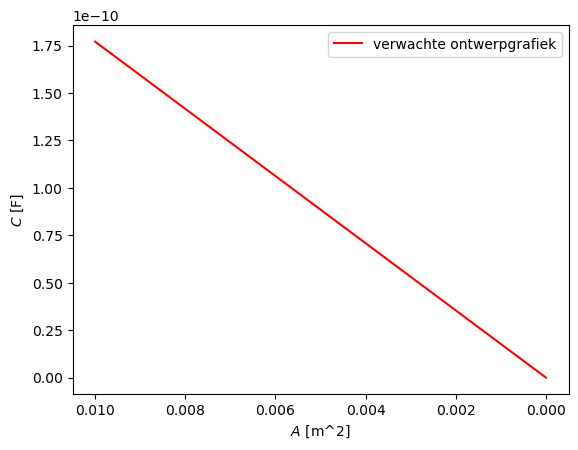

In [8]:
# Plot hier de verwachte ontwerpgrafiek van jullie sensoren.

A_var = np.linspace(0.01,0,1000) # (m^2) afnemend oppervlakte van 0.01 naar 0.

# Figuur plotten:
plt.figure()
plt.plot(A_var, vlakkeplaat(epsilonr_karton,A_var,d), "r-", label = "verwachte ontwerpgrafiek")
plt.xlabel("$A$ [m^2]")
plt.ylabel("$C$ [F]")
plt.legend()
plt.gca().invert_xaxis()
plt.show()

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 2 beheersen.

#### Voeg hier de foto's van je sensoren in actie in.
![meting 1a](m1.jpeg)
![meting 1b](mo1.jpeg)
![meting 2a](m2.jpeg)
![meting 2b](m02.jpeg)

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
![uitgewerkte schets](Ontwerp.jpeg)

In [9]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!
epsilon0 = 8.854e-12

def vlakkeplaat(epsilonr,A,d):
    C = (epsilon0 * epsilonr * A) / d     # Afstand tussen de twee platen << oppervlakte A platen. 
    return C


In [10]:
# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
# gaat zijn.

A = 0.01   # (m^2) oppervlakte platen
d = 0.001   # (m) afstand tussen de platen
epsilonr_karton = 2   # (F/m) permittiviteit van karton (stof tussen de platen)

C_verwacht = vlakkeplaat(epsilonr_karton,A,d) / 1e-12  # (pF)

print(f"Verwachte capaciteit plaatcondensator groep 19 is {C_verwacht:.1f} pF")



# Met osciloscoop berekend:
A_uit = 750e-3 # (V) amplitude van V_uit
A_in = 8    # (V)
f = 100e3   # (Hz) frequentie
R_sh = 1e3  # (Ohm) weerstand shunt
C_meting = A_uit / (2*np.pi*f*R_sh*A_in * 1e-12)

print(f"Berekende capaciteit plaatcondensator groep 19 is {C_meting:.1f} pF")


Verwachte capaciteit plaatcondensator groep 19 is 177.1 pF
Berekende capaciteit plaatcondensator groep 19 is 149.2 pF


kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 3 beheersen.

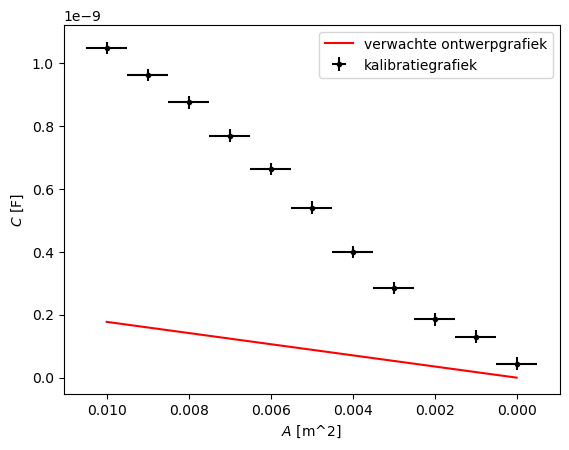

In [11]:
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.
A_kal = np.array([0.1,0.09,0.08,0.07,0.06,0.05,0.04,0.03,0.02,0.01,0])*0.1
C_kal = np.array([1047,960.5,874,768,662,540,399,285,185,130,44])*1e-12

plt.figure()
plt.plot(A_var, vlakkeplaat(epsilonr_karton,A_var,d), "r-", label = "verwachte ontwerpgrafiek")
plt.errorbar(A_kal, C_kal, xerr=0.0005, yerr=2e-11, fmt = "k.", label = "kalibratiegrafiek")
plt.xlabel("$A$ [m^2]")
plt.ylabel("$C$ [F]")
plt.legend()
plt.gca().invert_xaxis()
plt.show()


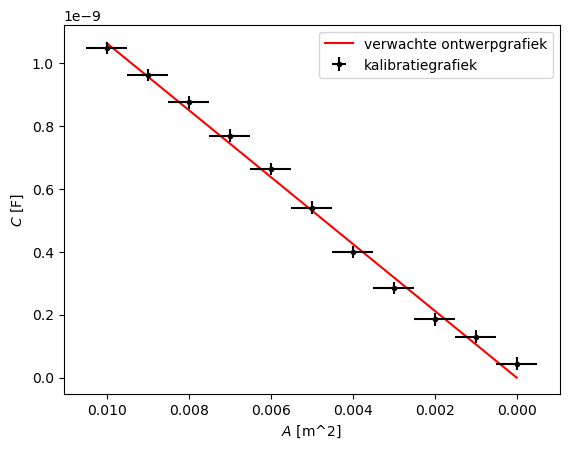

In [12]:
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.
A_kal = np.array([0.1,0.09,0.08,0.07,0.06,0.05,0.04,0.03,0.02,0.01,0])*0.1
C_kal = np.array([1047,960.5,874,768,662,540,399,285,185,130,44])*1e-12

plt.figure()
plt.plot(A_var, 6*vlakkeplaat(epsilonr_karton,A_var,d), "r-", label = "verwachte ontwerpgrafiek")
plt.errorbar(A_kal, C_kal, xerr=0.0005, yerr=2e-11, fmt = "k.", label = "kalibratiegrafiek")
plt.xlabel("$A$ [m^2]")
plt.ylabel("$C$ [F]")
plt.legend()
plt.gca().invert_xaxis()
plt.show()


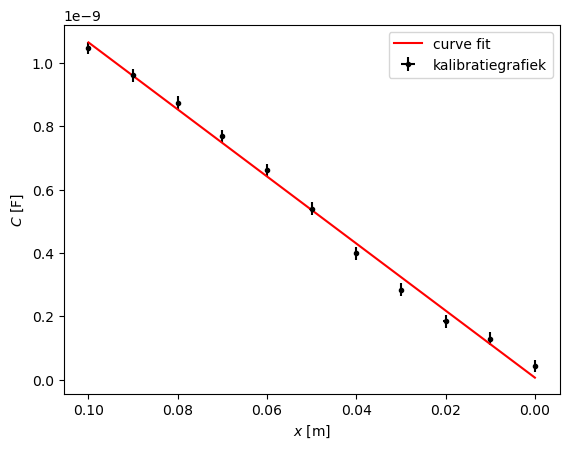

fit: C = 1.0575454423503925e-08*x + 7.090917662340709e-12


In [13]:
from scipy.optimize import curve_fit


x_kal = np.array([0.1,0.09,0.08,0.07,0.06,0.05,0.04,0.03,0.02,0.01,0])
C_kal = np.array([1047,960.5,874,768,662,540,399,285,185,130,44])*1e-12

def functiefit(x, k, b):
    return k * x + b

x_test = np.linspace(0, 0.1, 100)

# juiste curve_fit aanroep
popt, cov = curve_fit(functiefit, x_kal, C_kal)

k_fit = popt[0]
k_err = np.sqrt(cov[0,0])
b_fit = popt[1]
b_err = np.sqrt(cov[1,1])


plt.figure()
plt.errorbar(x_kal, C_kal, xerr=0.0005,yerr=2e-11,fmt="k.",label="kalibratiegrafiek")
plt.plot(x_test,functiefit(x_test, k_fit, b_fit), "r-", label="curve fit")
plt.xlabel("$x$ [m]")
plt.ylabel("$C$ [F]")
plt.legend()
plt.gca().invert_xaxis()
plt.show()

print(f"fit: C = {k_fit}*x + {b_fit}")